<a href="https://colab.research.google.com/github/KrithikChidM/PrmlLab/blob/main/LAB5/code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##EX1

In [6]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

Accuracy: 0.9396666666666667


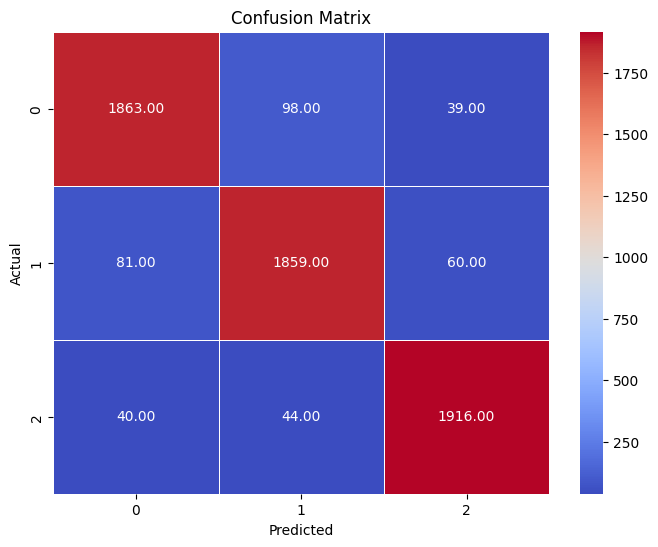

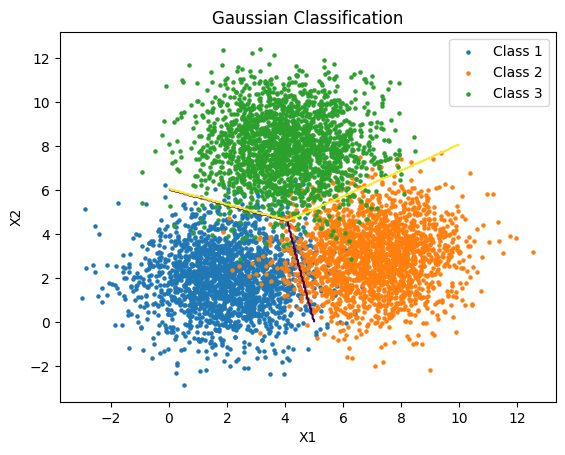

In [9]:
np.random.seed(42)

n = 10000
means = [np.array([2,2]), np.array([7,3]), np.array([4,8])]
cov = (1.5**2) * np.eye(2)

X = np.vstack([np.random.multivariate_normal(m, cov, n) for m in means])
y = np.repeat([0,1,2], n)

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

mu = [Xtr[ytr==i].mean(axis=0) for i in range(3)]
S = [np.cov(Xtr[ytr==i], rowvar=False) for i in range(3)]

def classify(x):
    p = []
    for i in range(3):
        d = x-mu[i]
        p.append(-0.5*d@np.linalg.inv(S[i])@d-0.5*np.log(np.linalg.det(S[i])))
    return np.argmax(p)

yp = np.array([classify(x) for x in Xte])

data = confusion_matrix(yte, yp)
print("Accuracy:", np.mean(yp == yte))

plt.figure(figsize=(8, 6))
sns.heatmap(
    data,
    annot=True,  # Show numbers inside the cells
    fmt=".2f",  # Format numbers to 2 decimal places
    cmap="coolwarm",  # Color palette (e.g., 'viridis', 'plasma', 'coolwarm')
    linewidths=0.5,  # Add subtle lines between cells
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

xx, yy = np.meshgrid(np.linspace(0,10,200), np.linspace(0,11,200))
Z = np.array([classify(x) for x in np.c_[xx.ravel(), yy.ravel()]]).reshape(xx.shape)

plt.contour(xx, yy, Z, levels=[0.5,1.5])
for i in range(3):
    plt.scatter(Xte[yte==i,0], Xte[yte==i,1], s=5, label=f"Class {i+1}")
plt.xlabel("X1"); plt.ylabel("X2")
plt.title("Gaussian Classification")
plt.legend()
plt.show()

Accuracy: 0.9435


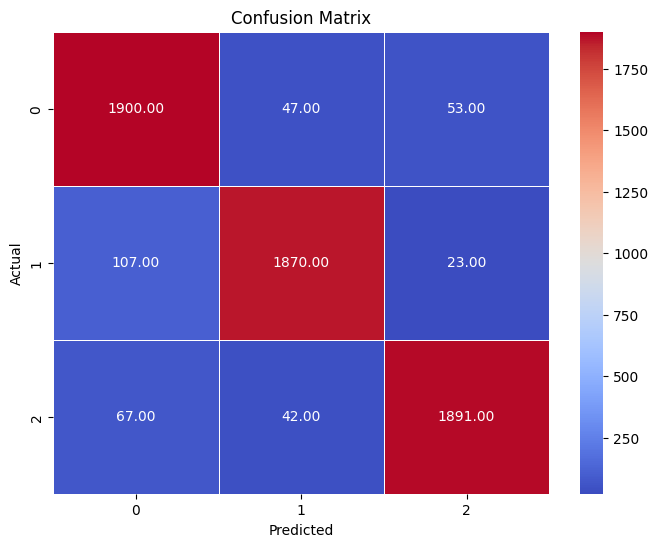

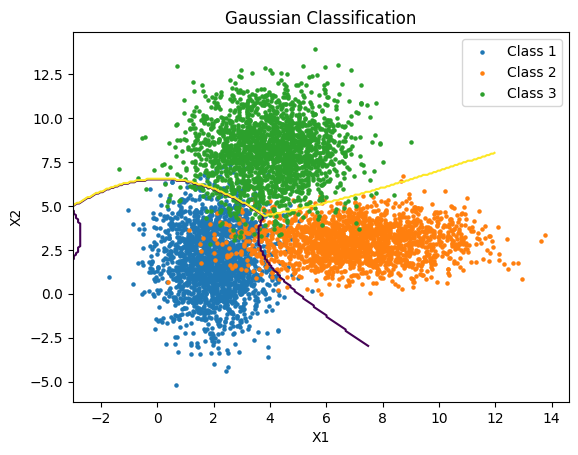

In [10]:
means = [np.array([2,2]), np.array([7,3]), np.array([4,8])]
covs = [np.diag([1,4]), np.diag([4,1]), np.diag([2,3])]

X = np.vstack([np.random.multivariate_normal(means[i], covs[i], n) for i in range(3)])
y = np.repeat([0,1,2], n)

Xtr,Xte,ytr,yte = train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

mu = [Xtr[ytr==i].mean(axis=0) for i in range(3)]
S = [np.cov(Xtr[ytr==i],rowvar=False) for i in range(3)]

def classify(x):
    p = []
    for i in range(3):
        d = x-mu[i]
        p.append(-0.5*d@np.linalg.inv(S[i])@d-0.5*np.log(np.linalg.det(S[i])))
    return np.argmax(p)

yp = np.array([classify(x) for x in Xte])

data = confusion_matrix(yte, yp)
print("Accuracy:", np.mean(yp == yte))

plt.figure(figsize=(8, 6))
sns.heatmap(
    data,
    annot=True,  # Show numbers inside the cells
    fmt=".2f",  # Format numbers to 2 decimal places
    cmap="coolwarm",  # Color palette (e.g., 'viridis', 'plasma', 'coolwarm')
    linewidths=0.5,  # Add subtle lines between cells
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

xx,yy = np.meshgrid(np.linspace(-3,12,200),np.linspace(-3,13,200))
Z = np.array([classify(x) for x in np.c_[xx.ravel(),yy.ravel()]]).reshape(xx.shape)

plt.contour(xx,yy,Z,levels=[0.5,1.5])
for i in range(3):
    plt.scatter(Xte[yte==i,0],Xte[yte==i,1],s=5,label=f"Class {i+1}")
plt.xlabel("X1"); plt.ylabel("X2")
plt.title("Gaussian Classification")
plt.legend(); plt.show()

Accuracy: 0.9408333333333333


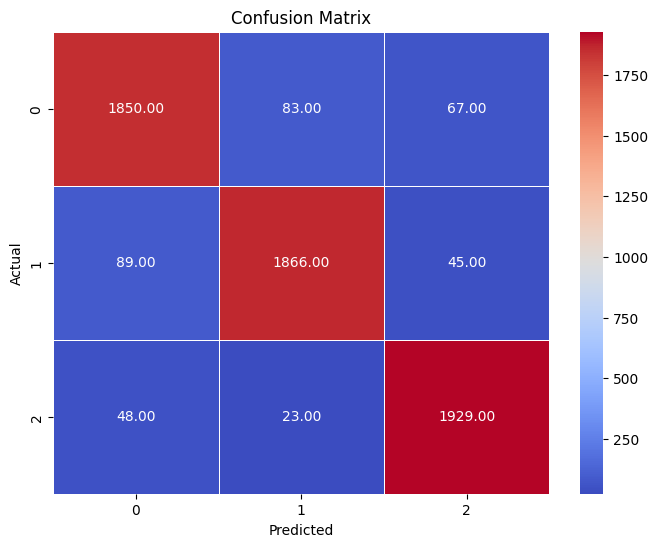

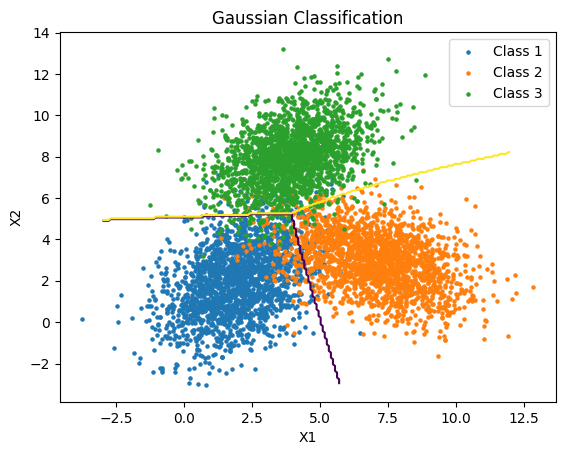

In [14]:
means = [np.array([2,2]), np.array([7,3]), np.array([4,8])]
covs = [np.array([[2,1],[1,3]]), np.array([[3,-1],[-1,2]]), np.array([[2,.8],[.8,2]])]

X = np.vstack([np.random.multivariate_normal(means[i],covs[i],n) for i in range(3)])
y = np.repeat([0,1,2],n)

Xtr,Xte,ytr,yte = train_test_split(X,y,test_size=.2,stratify=y,random_state=42)

mu = [Xtr[ytr==i].mean(axis=0) for i in range(3)]
S = [np.cov(Xtr[ytr==i],rowvar=False) for i in range(3)]

def classify(x):
    p = []
    for i in range(3):
        d = x-mu[i]
        p.append(-.5*d@np.linalg.inv(S[i])@d-.5*np.log(np.linalg.det(S[i])))
    return np.argmax(p)

yp = np.array([classify(x) for x in Xte])

data = confusion_matrix(yte, yp)
print("Accuracy:", np.mean(yp == yte))

plt.figure(figsize=(8, 6))
sns.heatmap(
    data,
    annot=True,  # Show numbers inside the cells
    fmt=".2f",  # Format numbers to 2 decimal places
    cmap="coolwarm",  # Color palette (e.g., 'viridis', 'plasma', 'coolwarm')
    linewidths=0.5,  # Add subtle lines between cells
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

xx,yy = np.meshgrid(np.linspace(-3,12,200),np.linspace(-3,13,200))
Z = np.array([classify(x) for x in np.c_[xx.ravel(),yy.ravel()]]).reshape(xx.shape)

plt.contour(xx,yy,Z,levels=[.5,1.5])
for i in range(3):
    plt.scatter(Xte[yte==i,0],Xte[yte==i,1],s=5,label=f"Class {i+1}")
plt.xlabel("X1"); plt.ylabel("X2")
plt.title("Gaussian Classification")
plt.legend(); plt.show()

##EX2